<a href="https://colab.research.google.com/github/anu-006/Customer_Segmentation/blob/main/Customer_Segmentation_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

In [59]:
data=pd.read_csv('customer_segmentation.csv')
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


Details of Features are as below:


Id: Unique identifier for each individual in the dataset.

Year_Birth: The birth year of the individual.

Education: The highest level of education attained by the individual.

Marital_Status: The marital status of the individual.

Income: The annual income of the individual.

Kidhome: The number of young children in the household.

Teenhome: The number of teenagers in the household.

Dt_Customer: The date when the customer was first enrolled or became a part of the company's database.

Recency: The number of days since the last purchase or interaction.

MntWines: The amount spent on wines.

MntFruits: The amount spent on fruits.

MntMeatProducts: The amount spent on meat products.

MntFishProducts: The amount spent on fish products.

MntSweetProducts: The amount spent on sweet products.

MntGoldProds: The amount spent on gold products.

NumDealsPurchases: The number of purchases made with a discount or as part of a deal.

NumWebPurchases: The number of purchases made through the company's website.

NumCatalogPurchases: The number of purchases made through catalogs.

NumStorePurchases: The number of purchases made in physical stores.

NumWebVisitsMonth: The number of visits to the company's website in a month.

AcceptedCmp3: Binary indicator (1 or 0) whether the individual accepted the third marketing campaign.

AcceptedCmp4: Binary indicator (1 or 0) whether the individual accepted the fourth marketing campaign.

AcceptedCmp5: Binary indicator (1 or 0) whether the individual accepted the fifth marketing campaign.

AcceptedCmp1: Binary indicator (1 or 0) whether the individual accepted the first marketing campaign.

AcceptedCmp2: Binary indicator (1 or 0) whether the individual accepted the second marketing campaign.

Complain: Binary indicator (1 or 0) whether the individual has made a complaint.

Z_CostContact: A constant cost associated with contacting a customer.

Z_Revenue: A constant revenue associated with a successful campaign response.

Response: Binary indicator (1 or 0) whether the individual responded to the marketing campaign.


In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [61]:
data.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [62]:
data=data.dropna()

In [63]:
data.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [64]:
data.duplicated().sum()

np.int64(0)

In [65]:
data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [66]:
import datetime

In [67]:
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], dayfirst=True)

/tmp/ipykernel_10839/547967645.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], dayfirst=True)


 Dates like '21-08-2013' are in Day-Month-Year format, but pd.to_datetime is expecting Month-Day-Year by default. To fix this, I will add dayfirst=True to the pd.to_datetime function, which will tell pandas to interpret the dates with the day first.

In [68]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [69]:

data['Education'].value_counts(ascending=False)

,count
Education,
Graduation,1116
PhD,481
Master,365
2n Cycle,200
Basic,54


In [70]:
data['Marital_Status'].value_counts(ascending=False)

,count
Marital_Status,
Married,857
Together,573
Single,471
Divorced,232
Widow,76
Alone,3
Absurd,2
YOLO,2


In [71]:
data['Total_Children']=data['Kidhome']+data['Teenhome']

/tmp/ipykernel_10839/323869722.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Total_Children']=data['Kidhome']+data['Teenhome']


In [72]:
data['Total_Children']

,Total_Children
0,0
1,2
2,0
3,1
4,1
...,...
2235,1
2236,3
2237,0
2238,1


In [73]:
data['Total_spend']=data['MntFishProducts']+data['MntFruits']+data['MntGoldProds']+data['MntMeatProducts']+data['MntSweetProducts']+data['MntWines']

/tmp/ipykernel_10839/2806343304.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Total_spend']=data['MntFishProducts']+data['MntFruits']+data['MntGoldProds']+data['MntMeatProducts']+data['MntSweetProducts']+data['MntWines']


In [74]:
data.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Children,Total_spend
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,3,11,1,0,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,3,11,0,2,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,3,11,0,0,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,3,11,0,1,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,3,11,0,1,422
5,7446,1967,Master,Together,62513.0,0,1,2013-09-09,16,520,...,0,0,0,0,0,3,11,0,1,716
6,965,1971,Graduation,Divorced,55635.0,0,1,2012-11-13,34,235,...,0,0,0,0,0,3,11,0,1,590
7,6177,1985,PhD,Married,33454.0,1,0,2013-05-08,32,76,...,0,0,0,0,0,3,11,0,1,169
8,4855,1974,PhD,Together,30351.0,1,0,2013-06-06,19,14,...,0,0,0,0,0,3,11,1,1,46
9,5899,1950,PhD,Together,5648.0,1,1,2014-03-13,68,28,...,0,0,0,0,0,3,11,0,2,49


In [75]:
data['Age']=2026-data['Year_Birth']

/tmp/ipykernel_10839/1340314385.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Age']=2026-data['Year_Birth']


In [76]:
data['Age']

,Age
0,69
1,72
2,61
3,42
4,45
...,...
2235,59
2236,80
2237,45
2238,70


In [77]:
from pandas.tseries.offsets import Day
data['customer_since(days)']=(datetime.datetime.now()-data['Dt_Customer']).dt.days

/tmp/ipykernel_10839/356589738.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['customer_since(days)']=(datetime.datetime.now()-data['Dt_Customer']).dt.days


In [78]:
data['customer_since(days)']

,customer_since(days)
0,5008
1,4458
2,4657
3,4484
4,4506
...,...
2235,4726
2236,4364
2237,4500
2238,4501


In [79]:
data.loc[:, 'Total_Cmp'] = data['AcceptedCmp1'] + data['AcceptedCmp2'] + data['AcceptedCmp3'] + data['AcceptedCmp4'] + data['AcceptedCmp5']

/tmp/ipykernel_10839/3762678680.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, 'Total_Cmp'] = data['AcceptedCmp1'] + data['AcceptedCmp2'] + data['AcceptedCmp3'] + data['AcceptedCmp4'] + data['AcceptedCmp5']


# Binnarisation on Total Campaigns column

In [80]:
def check_cmp(Total_Cmp):
  if Total_Cmp==0:
    return 0
  else:
    return 1


In [81]:
data['Total_Cmp']=data['Total_Cmp'].apply(check_cmp)

/tmp/ipykernel_10839/3019403051.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Total_Cmp']=data['Total_Cmp'].apply(check_cmp)


In [82]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Children,Total_spend,Age,customer_since(days),Total_Cmp
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,3,11,1,0,1617,69,5008,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,3,11,0,2,27,72,4458,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,3,11,0,0,776,61,4657,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,3,11,0,1,53,42,4484,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,3,11,0,1,422,45,4506,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,0,0,3,11,0,1,1341,59,4726,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,0,0,3,11,0,3,444,80,4364,1
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,0,0,3,11,0,0,1241,45,4500,1
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,0,0,3,11,0,1,843,70,4501,0


# Plotting Graph

In [83]:
data.drop(columns=['ID','Year_Birth','Kidhome','Teenhome','MntWines','MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds','Dt_Customer',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2'],inplace=True)

/tmp/ipykernel_10839/2350068732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns=['ID','Year_Birth','Kidhome','Teenhome','MntWines','MntFruits',


In [84]:
data

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Z_CostContact,Z_Revenue,Response,Total_Children,Total_spend,Age,customer_since(days),Total_Cmp
0,Graduation,Single,58138.0,58,3,8,10,4,7,0,3,11,1,0,1617,69,5008,0
1,Graduation,Single,46344.0,38,2,1,1,2,5,0,3,11,0,2,27,72,4458,0
2,Graduation,Together,71613.0,26,1,8,2,10,4,0,3,11,0,0,776,61,4657,0
3,Graduation,Together,26646.0,26,2,2,0,4,6,0,3,11,0,1,53,42,4484,0
4,PhD,Married,58293.0,94,5,5,3,6,5,0,3,11,0,1,422,45,4506,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduation,Married,61223.0,46,2,9,3,4,5,0,3,11,0,1,1341,59,4726,0
2236,PhD,Together,64014.0,56,7,8,2,5,7,0,3,11,0,3,444,80,4364,1
2237,Graduation,Divorced,56981.0,91,1,2,3,13,6,0,3,11,0,0,1241,45,4500,1
2238,Master,Together,69245.0,8,2,6,5,10,3,0,3,11,0,1,843,70,4501,0


# Numerical Columns

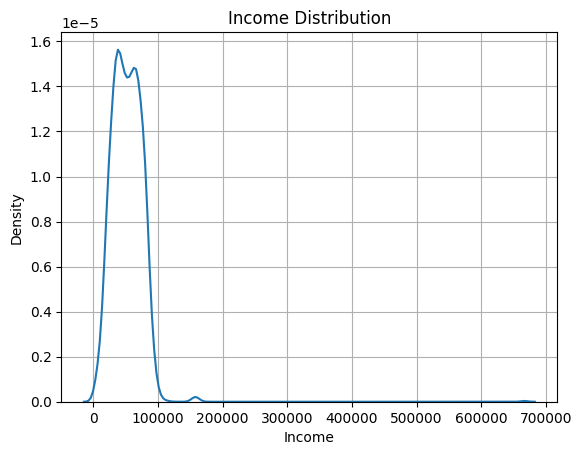

In [85]:
sns.kdeplot(data['Income'])
plt.title('Income Distribution')
plt.grid()

Text(0.5, 1.0, 'Age Distribution')

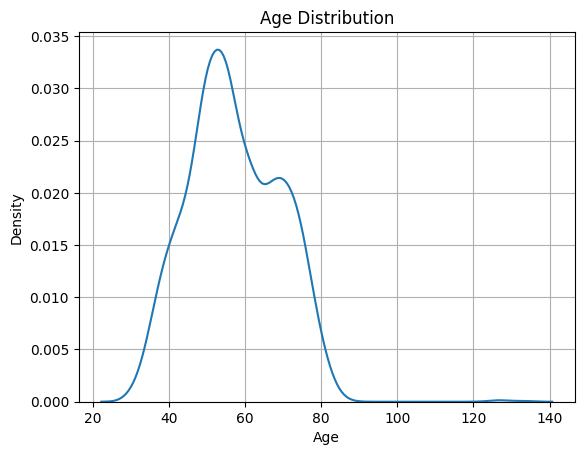

In [86]:
sns.kdeplot(data['Age'])
plt.grid()
plt.title('Age Distribution')

Text(0.5, 1.0, 'Total Money Spent')

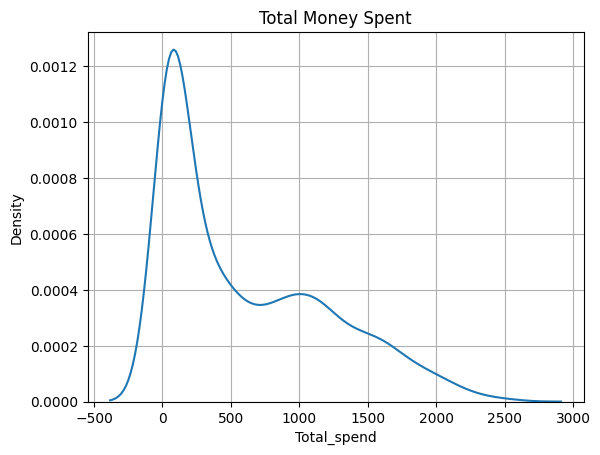

In [87]:
sns.kdeplot(data['Total_spend'])
plt.grid()
plt.title('Total Money Spent')

# Categorical Columns

In [88]:
grp1=data.groupby('Education')['Total_spend'].mean().sort_values(ascending=False)
grp1

,Total_spend
Education,
PhD,676.733888
Graduation,621.686380
Master,609.767123
2n Cycle,494.930000
Basic,81.796296


<Axes: xlabel='Education', ylabel='Total_spend'>

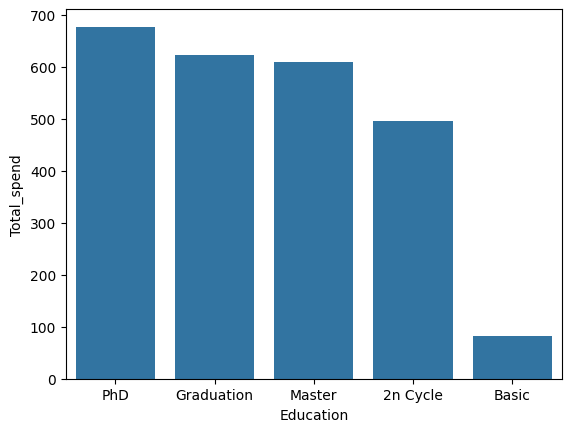

In [89]:
sns.barplot(grp1)

In [90]:
grp2=data.groupby('Marital_Status')['Total_spend'].mean().sort_values(ascending=False)
grp2

,Total_spend
Marital_Status,
Absurd,1192.500000
Widow,727.960526
Single,612.592357
Divorced,610.629310
Together,608.846422
Married,591.464411
YOLO,424.000000
Alone,256.666667


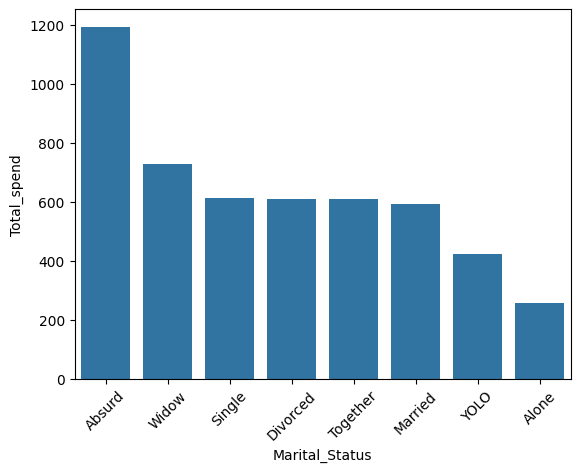

In [91]:
sns.barplot(grp2)
plt.xticks(rotation=45)
plt.show()

In [92]:
grp3=data.groupby('Education')['Total_Cmp'].mean().sort_values(ascending=False)
grp3

,Total_Cmp
Education,
PhD,0.237006
Graduation,0.204301
Master,0.202740
2n Cycle,0.185000
Basic,0.111111


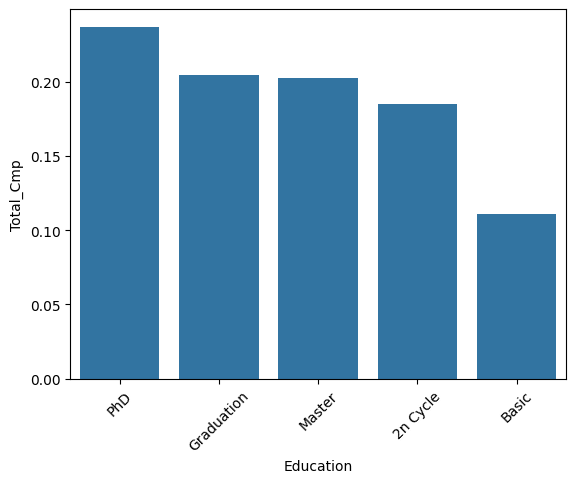

In [93]:
sns.barplot(grp3)
plt.xticks(rotation=45)
plt.show()

In [94]:
grp4=data.groupby('Marital_Status')['Total_Cmp'].mean().sort_values(ascending=False)
grp4

,Total_Cmp
Marital_Status,
Absurd,0.500000
Alone,0.333333
Widow,0.236842
Married,0.211202
Single,0.205945
Together,0.200698
Divorced,0.198276
YOLO,0.000000


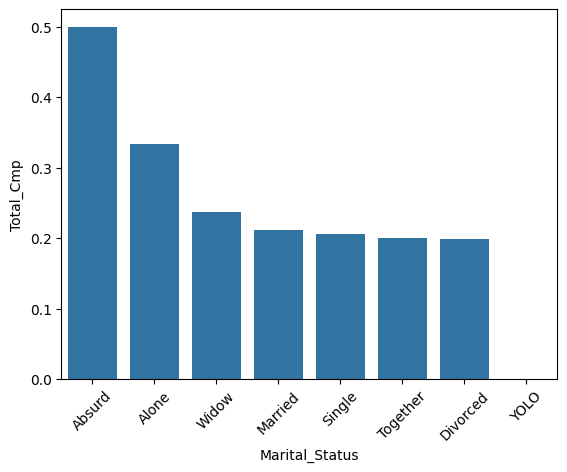

In [95]:
sns.barplot(grp4)
plt.xticks(rotation=45)
plt.show()

In [96]:
data.columns

Index(['Education', 'Marital_Status', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Z_CostContact', 'Z_Revenue',
       'Response', 'Total_Children', 'Total_spend', 'Age',
       'customer_since(days)', 'Total_Cmp'],
      dtype='object')

In [97]:
num=data[['Income', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain',
       'Response', 'Total_spend', 'Age',
       'customer_since(days)', 'Total_Cmp']].corr()

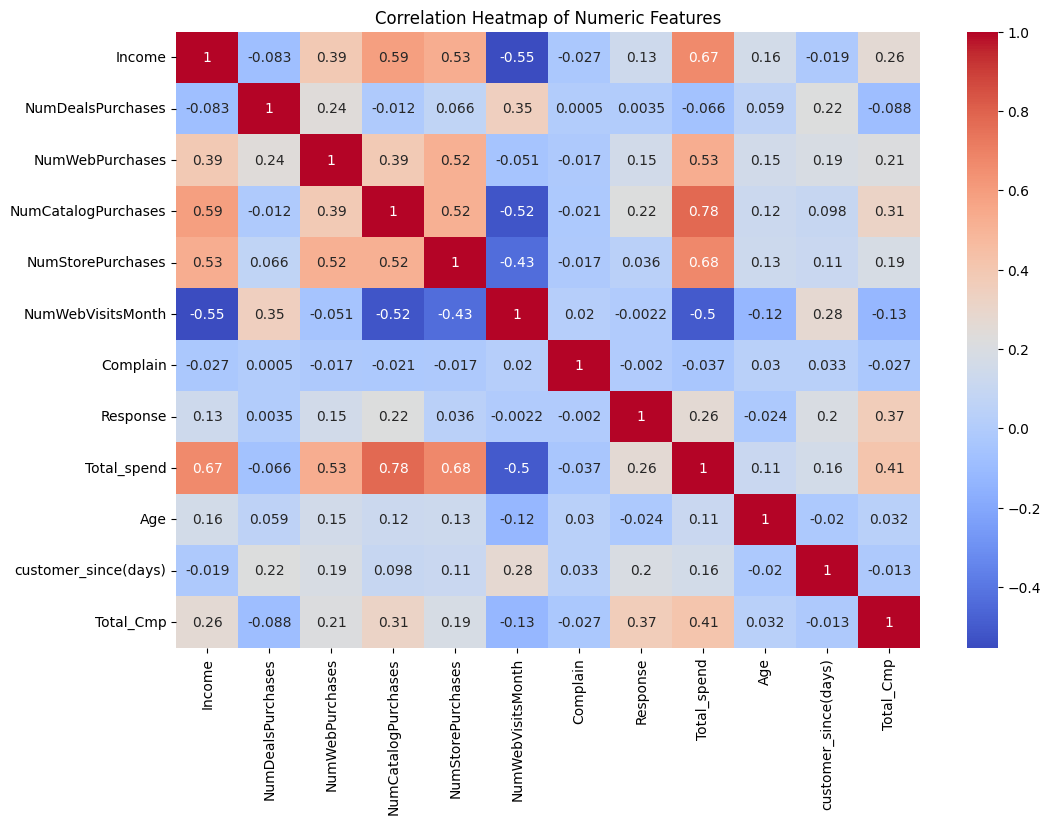

In [98]:
plt.figure(figsize=(12,8))
sns.heatmap(num, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

#Binning on age

In [99]:
def bin_age(age):
  if age>=18 and age<=29:
    return '18-29'

  elif age>=30 and age<=39:
    return '30-39'

  elif age>=40 and age<=49:
    return '40-49'

  elif age>=50 and age<=59:
    return '50-59'

  elif age>=60 and age<=69:
    return '60-69'
  else:
   return '70+'

In [100]:
data['Age']=data['Age'].apply(bin_age)

/tmp/ipykernel_10839/2742792984.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Age']=data['Age'].apply(bin_age)


In [101]:
data['Age']

,Age
0,60-69
1,70+
2,60-69
3,40-49
4,40-49
...,...
2235,50-59
2236,70+
2237,40-49
2238,70+


In [102]:
data

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Z_CostContact,Z_Revenue,Response,Total_Children,Total_spend,Age,customer_since(days),Total_Cmp
0,Graduation,Single,58138.0,58,3,8,10,4,7,0,3,11,1,0,1617,60-69,5008,0
1,Graduation,Single,46344.0,38,2,1,1,2,5,0,3,11,0,2,27,70+,4458,0
2,Graduation,Together,71613.0,26,1,8,2,10,4,0,3,11,0,0,776,60-69,4657,0
3,Graduation,Together,26646.0,26,2,2,0,4,6,0,3,11,0,1,53,40-49,4484,0
4,PhD,Married,58293.0,94,5,5,3,6,5,0,3,11,0,1,422,40-49,4506,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduation,Married,61223.0,46,2,9,3,4,5,0,3,11,0,1,1341,50-59,4726,0
2236,PhD,Together,64014.0,56,7,8,2,5,7,0,3,11,0,3,444,70+,4364,1
2237,Graduation,Divorced,56981.0,91,1,2,3,13,6,0,3,11,0,0,1241,40-49,4500,1
2238,Master,Together,69245.0,8,2,6,5,10,3,0,3,11,0,1,843,70+,4501,0


In [103]:
grp5=data.groupby('Age')['Total_spend'].mean().sort_values(ascending=False)
grp5

,Total_spend
Age,
70+,736.343675
30-39,680.582192
60-69,662.791667
50-59,546.461646
40-49,500.953744


<Axes: xlabel='Age', ylabel='Total_spend'>

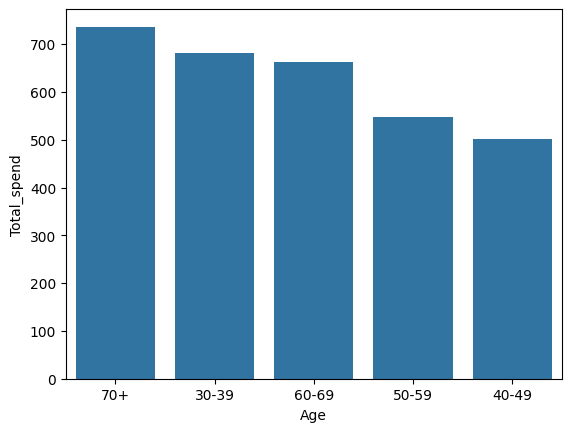

In [104]:
sns.barplot(grp5)

In [105]:
grp6=data.groupby('Age')['Income'].mean().sort_values(ascending=False)
grp6

,Income
Age,
70+,58506.286396
60-69,55373.906250
50-59,50080.818689
30-39,48679.664384
40-49,47733.748899


([0, 1, 2, 3, 4],
 [Text(0, 0, '70+'),
  Text(1, 0, '60-69'),
  Text(2, 0, '50-59'),
  Text(3, 0, '30-39'),
  Text(4, 0, '40-49')])

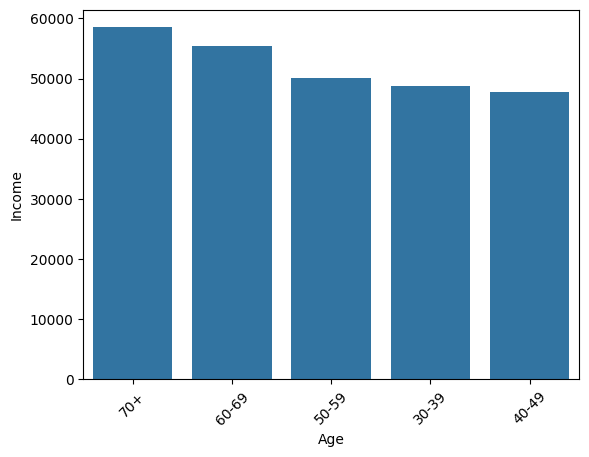

In [106]:
sns.barplot(grp6)
plt.xticks(rotation=45)

In [107]:
data.columns

Index(['Education', 'Marital_Status', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Z_CostContact', 'Z_Revenue',
       'Response', 'Total_Children', 'Total_spend', 'Age',
       'customer_since(days)', 'Total_Cmp'],
      dtype='object')

In [108]:
features = ['Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response',
       'Total_spend', 'customer_since(days)', 'Total_Cmp']

In [109]:
features

['Income',
 'Recency',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'Complain',
 'Response',
 'Total_spend',
 'customer_since(days)',
 'Total_Cmp']

# Standardisation

In [110]:
from sklearn.preprocessing import StandardScaler

In [111]:
scale=StandardScaler()
scaled_features=scale.fit_transform(data[features])
scaled_features

array([[ 0.2340627 ,  0.31053212,  0.35171348, ...,  1.67548812,
         1.52912861, -0.51111716],
       [-0.23455948, -0.38050944, -0.1682312 , ..., -0.96235832,
        -1.18841056, -0.51111716],
       [ 0.76947764, -0.79513438, -0.68817587, ...,  0.28024985,
        -0.20515548, -0.51111716],
       ...,
       [ 0.18809052,  1.4507507 , -0.68817587, ...,  1.05169551,
        -0.98088939,  1.95649858],
       [ 0.67538765, -1.41707178, -0.1682312 , ...,  0.39140438,
        -0.97594841, -0.51111716],
       [ 0.02470453, -0.31140528,  0.35171348, ..., -0.7218    ,
         1.32654842, -0.51111716]])

# Elbow Metthod

In [112]:
wcss=[]

for i in range(1,11):

  km=KMeans(n_clusters=i,random_state=42)
  km.fit_predict(scaled_features)
  wcss.append(km.inertia_)

In [113]:
wcss

[26592.00000000009,
 19943.502682983984,
 17780.528768597425,
 15744.87327626788,
 14327.127213987973,
 13530.43330332955,
 12944.943786808408,
 12175.527178747147,
 11703.309685026066,
 11133.502957728277]

# Graph for Elbow Method

<Axes: >

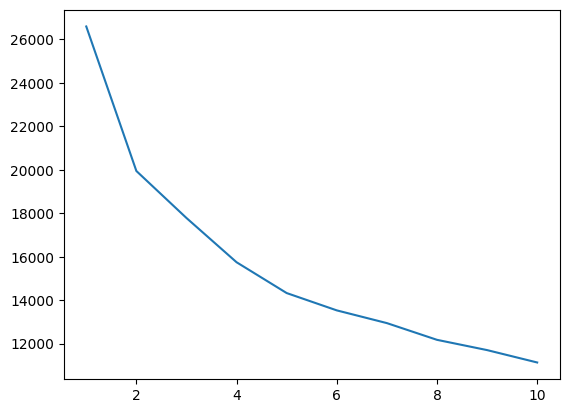

In [114]:
sns.lineplot(x=range(1,11),y=wcss)

In [115]:
km=KMeans(n_clusters=4)
data['output_cluster']=km.fit_predict(scaled_features)
data['output_cluster']


/tmp/ipykernel_10839/1802004689.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['output_cluster']=km.fit_predict(scaled_features)


,output_cluster
0,2
1,0
2,1
3,0
4,3
...,...
2235,1
2236,3
2237,1
2238,1


In [116]:
grp_cluster=data.groupby('output_cluster')[features].mean().sort_values(by='Income', ascending=False)

In [117]:
grp_cluster

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Total_spend,customer_since(days),Total_Cmp
output_cluster,,,,,,,,,,,,
2,75412.024752,38.485149,1.460396,5.915842,6.039604,7.475248,3.896040,0.004950,1.000000,1449.143564,4772.509901,0.727723
1,73481.795491,51.917874,1.608696,5.291465,5.095008,8.692432,3.122383,0.006441,0.000000,1134.661836,4654.690821,0.268921
3,50950.011792,50.457547,4.938679,6.228774,2.429245,6.688679,6.929245,0.009434,0.143868,612.254717,4835.841981,0.172170
0,34377.378741,48.713106,1.817337,1.992776,0.521156,3.210526,6.318885,0.012384,0.072239,91.156863,4651.100103,0.074303


Cluster 0 = high income,high spending group , higher catalogue and higher store purchases

Cluster 1  = Moderate income, moderate spending, fewer purchases

Cluster 2 = Inactive customers

Cluster3 = high income,high spending group ,higher deals and higher web purchases (Digital Customers)


In [118]:
pca=PCA(n_components=6)
data_pca=pca.fit_transform(scaled_features)
data_pca

array([[ 2.26518025,  2.34490326,  0.8001186 ,  0.35959672,  0.65541073,
         1.27084477],
       [-1.78939321, -1.3485586 ,  0.31434188, -0.30806998, -0.40594222,
        -0.34218574],
       [ 1.29118779, -0.33211507, -0.63016297, -0.51528509, -1.21169845,
         0.10114321],
       ...,
       [ 1.53239562, -0.96889245, -0.2128058 ,  0.34795322,  1.61735131,
        -1.1562308 ],
       [ 1.59686578, -0.87866779, -0.37244126, -0.77071424, -1.81943378,
        -0.22904036],
       [-0.82997056,  1.63258671,  1.51588716,  0.13113851,  0.08017772,
         1.1565716 ]])

/tmp/ipykernel_10839/923498496.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, 'Cluster_Label'] = [label_map[l] for l in data['output_cluster']]


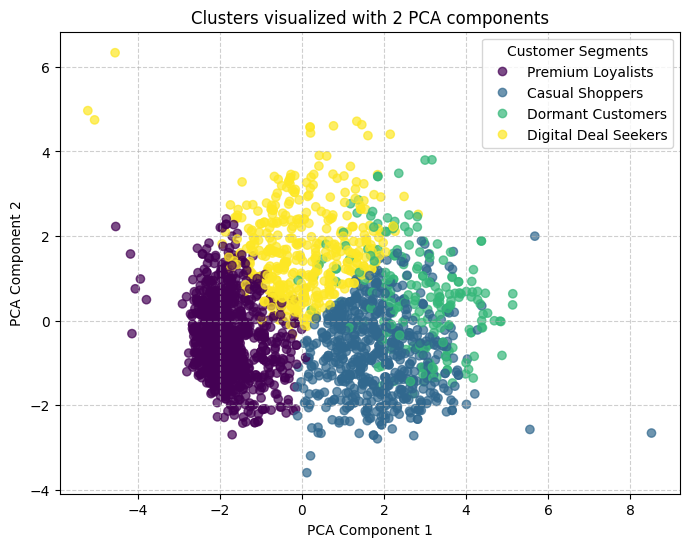

In [120]:
pca_vis = PCA(n_components=2, random_state=42)
X_vis = pca_vis.fit_transform(scaled_features)

# Define cluster label mapping
label_map = {
    0: 'Premium Loyalists',
    1: 'Casual Shoppers',
    2: 'Dormant Customers',
    3: 'Digital Deal Seekers'
}

# Safely assign labels using .loc
data.loc[:, 'Cluster_Label'] = [label_map[l] for l in data['output_cluster']]

# Plot clusters
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_vis[:,0], X_vis[:,1], c=data['output_cluster'], cmap='viridis', alpha=0.7)
plt.title('Clusters visualized with 2 PCA components')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, linestyle='--', alpha=0.6);

# Add legend with cluster names
handles, _ = scatter.legend_elements()
plt.legend(handles, label_map.values(), title="Customer Segments")
plt.show()